# **Validación de resultados**

## 1. Definición de rutas

In [51]:
from pathlib import Path

import polars as pl

ROOT = Path.cwd()
OUT_DIR = ROOT / "data" / "output"
if not OUT_DIR.exists():
    OUT_DIR = ROOT.parent / "data" / "output"

parquet_path = OUT_DIR / "forecast_seccion_1_partial.parquet"
if not parquet_path.exists():
    raise FileNotFoundError(f"Parquet file not found: {parquet_path}")

df = pl.read_parquet(parquet_path)

## 2. Función graficadora

In [52]:
import matplotlib.pyplot as plt


def graph_plot(filtered: pl.DataFrame, unique_id: str):
    x = filtered["ds"].to_list()
    y_value = filtered["value"].to_list()
    y_valuehat = filtered["valuehat"].to_list()

    plt.figure(figsize=(12, 5))
    plt.plot(x, y_value, label="value", linewidth=1)
    plt.plot(x, y_valuehat, label="valuehat", linewidth=1)
    plt.xlabel("ds")
    plt.ylabel("series")
    plt.title(f"Series value y valuehat para UNIQUE_ID={unique_id}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 3. Resultados Sección 1

shape: (5, 3)
┌────────────┬──────────┬──────────┐
│ ds         ┆ value    ┆ valuehat │
│ ---        ┆ ---      ┆ ---      │
│ date       ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╡
│ 2024-05-26 ┆ 2.1347e6 ┆ 2.0427e6 │
│ 2024-05-27 ┆ 1.9304e6 ┆ 2.0117e6 │
│ 2024-05-28 ┆ 2.0906e6 ┆ 2.2787e6 │
│ 2024-05-29 ┆ 1.8514e6 ┆ 1.9099e6 │
│ 2024-05-30 ┆ 1.7116e6 ┆ 1.8177e6 │
└────────────┴──────────┴──────────┘


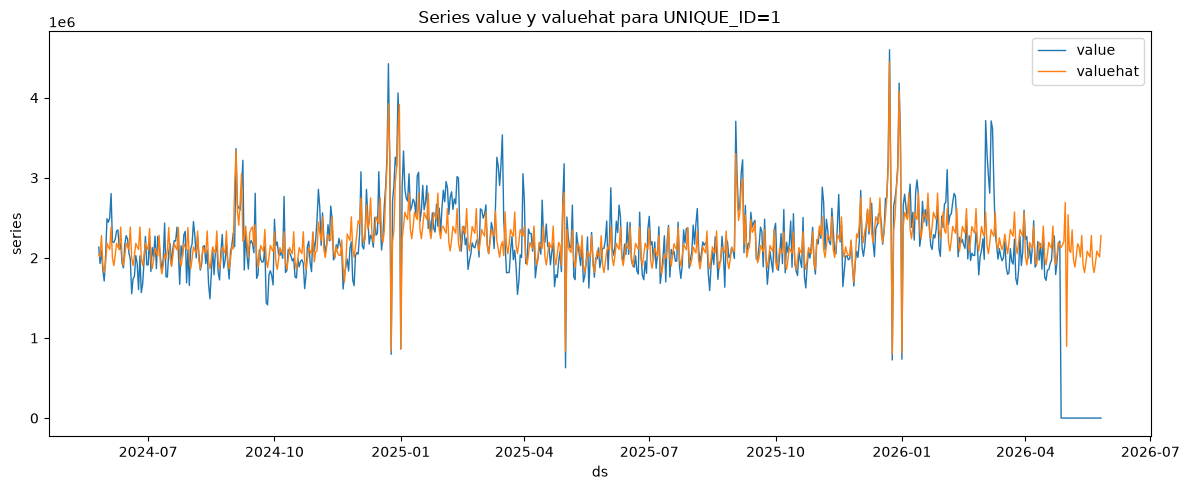

In [53]:
filtered = (
    df.filter(pl.col("unique_id") == "1").select(["ds", "value", "valuehat"]).sort("ds")
)

print(filtered.head())

graph_plot(filtered, "1")


## 4. Resultados Tienda 00063

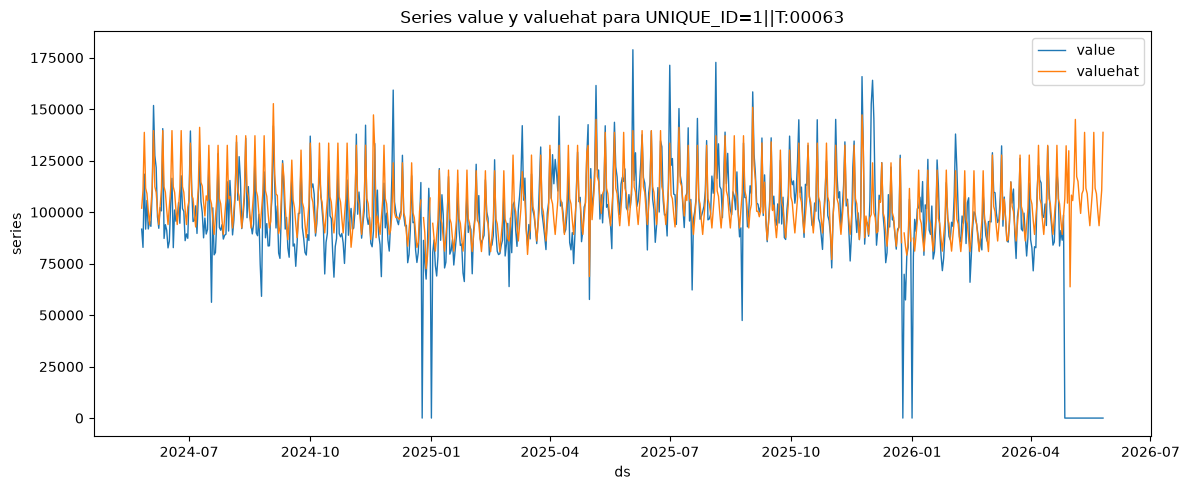

In [54]:
unique_id = "1||T:00063"

filtered = (
    df.filter(pl.col("unique_id") == unique_id)
    .select(["ds", "value", "valuehat"])
    .sort("ds")
)

graph_plot(filtered, unique_id)

## 5. Selección de SKU

In [55]:
import polars as pl

unique_id = "T:00063||S:"

qry = (
    df.filter(pl.col("unique_id").str.contains(unique_id, literal=True))
    .select(["unique_id", "ds", "value", "valuehat"])
    .with_columns((pl.col("valuehat") / pl.col("value")).alias("ratio"))
    .filter(pl.col("ratio").is_between(0.8, 1.2, closed="none"))
    .sort("ds")
)

qry

unique_id,ds,value,valuehat,ratio
str,date,f64,f64,f64
"""1||T:00063||S:108193""",2026-03-30,102.0,122.17,1.197745
"""1||T:00063||S:110852""",2026-03-30,200.6,209.11,1.042423
"""1||T:00063||S:156703""",2026-03-30,1397.5,1263.53,0.904136
"""1||T:00063||S:26839""",2026-03-30,119.0,125.25,1.052521
"""1||T:00063||S:402255""",2026-03-30,145.0,139.7,0.963448
…,…,…,…,…
"""1||T:00063||S:525569""",2026-04-26,255.0,234.03,0.917765
"""1||T:00063||S:541426""",2026-04-26,400.0,362.95,0.907375
"""1||T:00063||S:565117""",2026-04-26,328.0,279.82,0.85311


## 6. Probemos con 1||T:00211||S:495934

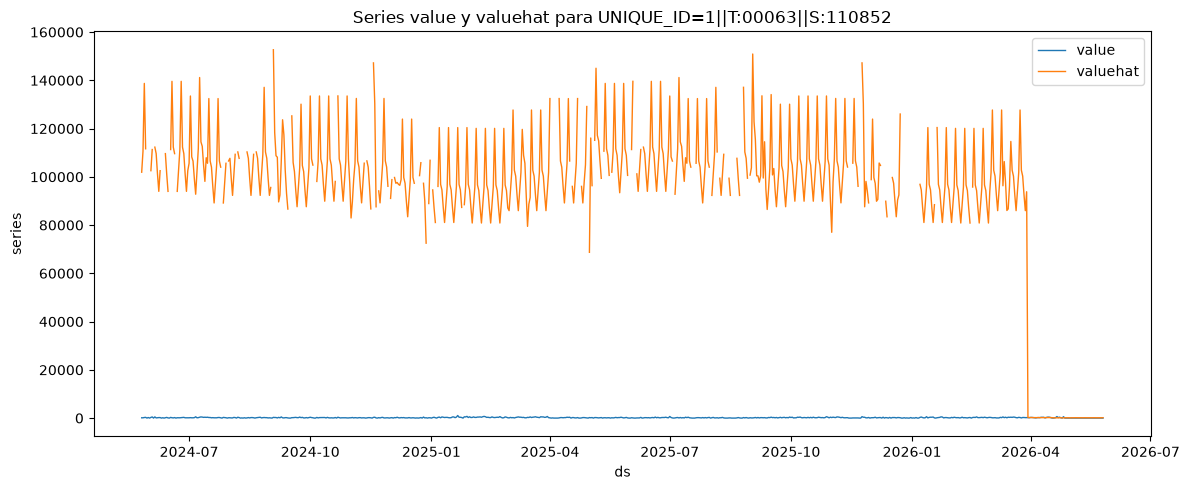

In [56]:
unique_id = "1||T:00063||S:110852"

filtered = (
    df.filter(pl.col("unique_id") == unique_id)
    # .select(["ds", "value", "valuehat"])
    .sort("ds")
)

filtered.write_parquet(OUT_DIR / f"forecast_{'1__T_00063__S_110852'}.parquet")

graph_plot(filtered, unique_id)

In [ ]:
wmape_path = OUT_DIR / "wmape.parquet"

df_wmape = pl.read_parquet(wmape_path)
df_wmape.filter(
    (pl.col("wmape") != 0) & pl.col("unique_id").str.starts_with("1||")
).sort("wmape", descending=False)

In [ ]:
df.filter(
    (pl.col("unique_id") == "1||T:00063") & (pl.col("period_type") == "forecast_only")
).sort("ds")